<a href="https://colab.research.google.com/github/brindha22001-wq/Brindha-D/blob/main/MILESTONE_PROJECT_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

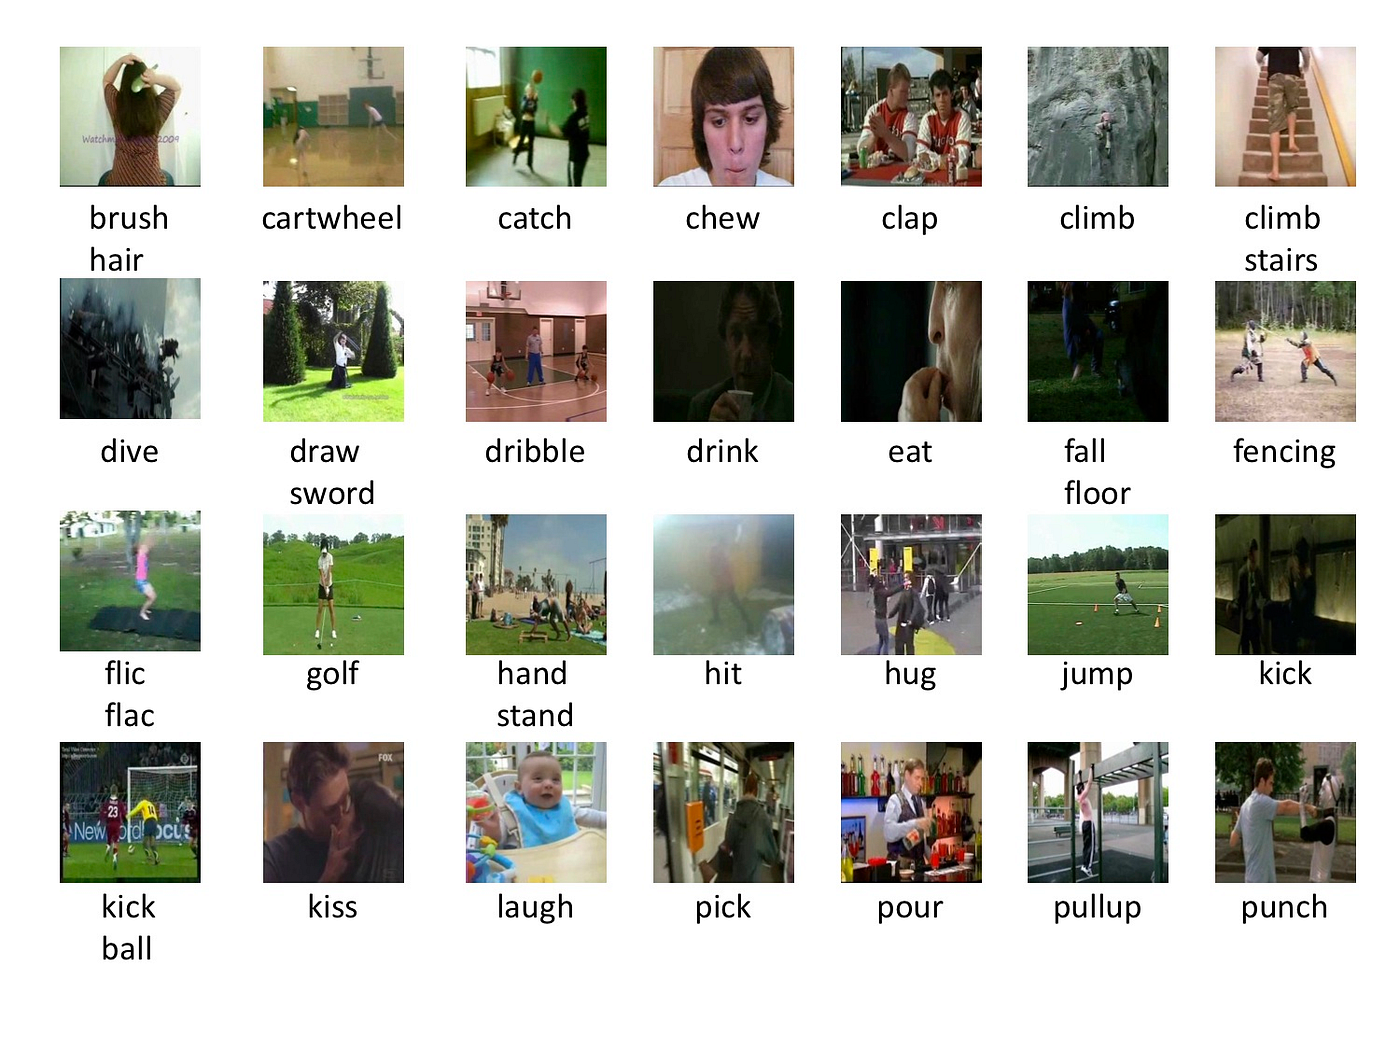

In [ ]:
!pip install tensorflow opencv-python matplotlib scikit-learn tqdm kagglehub

This cell imports various modules and libraries essential for the project:

*   **Standard Libraries:**
    *   `os`: For interacting with the operating system, like listing directory contents.
    *   `cv2` (OpenCV): For image processing tasks such as reading images (`cv2.imread`) and resizing them (`cv2.resize`).
    *   `random`: For generating random numbers, used here for shuffling video IDs.
    *   `numpy`: For numerical operations, especially with arrays, which are fundamental for image and model data.
    *   `matplotlib.pyplot`: For creating static, interactive, and animated visualizations, used for plotting the confusion matrix.
    *   `tqdm`: For displaying progress bars during iterative processes, useful for tracking data loading and feature extraction.

*   **Scikit-learn (`sklearn`):**
    *   `train_test_split`: For dividing datasets into training, validation, and test subsets.
    *   `LabelEncoder`: For encoding categorical labels into numerical formats.
    *   `confusion_matrix`, `classification_report`: For evaluating model performance.

*   **TensorFlow / Keras:**
    *   `tensorflow`: The core deep learning library.
    *   `Sequential`, `Model`: For building neural network models.
    *   `Conv2D`, `MaxPooling2D`, `Flatten`, `Dense`, `Dropout`: Layers for constructing Convolutional Neural Networks (CNNs).
    *   `TimeDistributed`, `LSTM`, `Input`: Layers for building sequence models, particularly the hybrid CNN-LSTM.
    *   `Adam`: An optimizer for training neural networks.
    *   `to_categorical`: For converting integer labels into one-hot encoded vectors.

In [ ]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


# Scikit-learn
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

# TensorFlow / Keras
# ===============================
import tensorflow
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout,
    TimeDistributed, LSTM, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

This cell downloads the UCF101-frames dataset from KaggleHub. The `kagglehub.dataset_download` function fetches the dataset, and the `path` variable stores the local directory where the dataset files are located. This is a crucial first step in obtaining the necessary data for the action recognition project.

In [ ]:
# Download latest version
path = kagglehub.dataset_download("pevogam/ucf101-frames")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/pevogam/ucf101-frames/versions/2


This cell defines key parameters for the project. `IMG_SIZE` sets the dimension for resizing images (80x80 pixels), `SEQUENCE_LENGTH` specifies the number of frames to consider per video (7 frames), `NUM_CLASSES` limits the number of action categories to be used (6 classes), and `VIDEOS_PER_CLASS` defines how many videos to sample from each class (30 videos). A `RANDOM_SEED` is also set for reproducibility across runs.

In [ ]:
IMG_SIZE = 80
SEQUENCE_LENGTH = 7
NUM_CLASSES = 6
VIDEOS_PER_CLASS = 30
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


This cell sets the path to the training data within the downloaded dataset. It then lists all available action classes, sorts them, and selects the first NUM_CLASSES (which is 6, as defined earlier) to be used in the project. Finally, it prints the names of these selected classes, providing an overview of the action categories the model will be trained on.

In [ ]:
DATASET_PATH_TRAIN = os.path.join(path, 'train')
all_classes = sorted(os.listdir(DATASET_PATH_TRAIN))
selected_classes = all_classes[:NUM_CLASSES]

print("Selected Classes:")
for c in selected_classes:
    print("- ", c)


Selected Classes:
-  ApplyEyeMakeup
-  ApplyLipstick
-  Archery
-  BabyCrawling
-  BalanceBeam
-  BandMarching


This cell defines and executes the `sample_videos` function. This function iterates through the `selected_classes` and identifies unique video identifiers within each class. It then shuffles and selects `VIDEOS_PER_CLASS` unique videos from each chosen action category. The function returns a list of `(video_id, class_path)` tuples and their corresponding labels, effectively creating a balanced sample of videos for training.

In [ ]:
def sample_videos(dataset_path, classes, max_videos):
    video_identifiers = []
    labels = []

    for label in classes:
        class_path = os.path.join(dataset_path, label)
        all_frames = os.listdir(class_path)

        # Extract unique video IDs from filenames (e.g., 'v_ApplyEyeMakeup_g01_c01' from 'v_ApplyEyeMakeup_g01_c01-0001.jpg')
        unique_video_ids = set()
        for frame_filename in all_frames:
            if '-' in frame_filename and frame_filename.endswith('.jpg'):
                video_id = frame_filename.split('-')[0]
                unique_video_ids.add(video_id)

        unique_video_ids = list(unique_video_ids)
        random.shuffle(unique_video_ids)

        selected_video_ids = unique_video_ids[:max_videos]

        for vid_id in selected_video_ids:
            # Store video_id and its class_path so load_video can find frames
            video_identifiers.append((vid_id, class_path))
            labels.append(label)
    return video_identifiers, labels

# video_data will now be a list of (video_id_string, class_path) tuples
video_data, video_labels = sample_videos(
    DATASET_PATH_TRAIN, selected_classes, VIDEOS_PER_CLASS
)

print("Total videos (unique identifiers):", len(video_data))


Total videos (unique identifiers): 180


This cell defines the load_video function. This function takes a video_id and its class_path to load a sequence of frames for a specific video. It filters the frames belonging to the video_id, resizes them to IMG_SIZE, normalizes pixel values (0-255 to 0-1), and pads with zeros if fewer than SEQUENCE_LENGTH frames are available. This ensures consistent input dimensions for the models.

In [ ]:
def load_video(video_id, class_path): # Changed signature
    all_frames_in_class = sorted(os.listdir(class_path))

    # Filter frames belonging to this specific video_id
    video_frames_filenames = [
        f for f in all_frames_in_class if f.startswith(video_id) and f.endswith('.jpg')
    ]
 # Take only SEQUENCE_LENGTH frames
    selected_frames = video_frames_filenames[:SEQUENCE_LENGTH]

    sequence = []
    for f_name in selected_frames:
        img_path = os.path.join(class_path, f_name)
        img = cv2.imread(img_path)
        # Handle potential None from imread (e.g., corrupted file)
        if img is None:
            print(f"Warning: Could not read image {img_path}. Skipping.")
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        sequence.append(img)

    # Pad with zeros if fewer than SEQUENCE_LENGTH frames
    while len(sequence) < SEQUENCE_LENGTH:
        sequence.append(np.zeros((IMG_SIZE, IMG_SIZE, 3)))

    return np.array(sequence)

This cell defines and compiles the first model, a basic Convolutional Neural Network (CNN). This CNN is designed to classify a single image (frame). It consists of two `Conv2D` layers with `MaxPooling2D`, followed by a `Flatten` layer, a `Dense` hidden layer with `Dropout`, and a final `Dense` output layer with `softmax` activation for classification across `NUM_CLASSES`. The model is compiled with the Adam optimizer and `categorical_crossentropy` loss. The `cnn.summary()` command displays the network architecture and parameter count.

In [ ]:
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 78, 78, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 39, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,674,502 (10.20 MB)

 Trainable params: 2,674,502 (10.20 MB)

 Non-trainable params: 0 (0.00 B)

This cell processes the sampled video data. It iterates through the `video_data` (which contains video IDs and their class paths) and `video_labels`. For each video, it calls the `load_video` function to load its frames into `X` and appends the corresponding `label` to `y`. Finally, it converts `X` and `y` into NumPy arrays, showing their shapes. `X` will contain sequences of frames, and `y` will contain the categorical labels.

In [ ]:
X = []
y = []

# video_data is now a list of (video_id_string, class_path) tuples
for (video_id, class_path), label in tqdm(zip(video_data, video_labels), total=len(video_data)):
    X.append(load_video(video_id, class_path)) # Call with new signature
    y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape: ", X.shape)
print("y shape: ", y.shape)

100%|██████████| 180/180 [00:02<00:00, 69.29it/s]


X shape:  (180, 7, 80, 80, 3)
y shape:  (180,)


In [ ]:
cnn.fit(
    X_train[:,0],
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=32
)

Epoch 1/8
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 216ms/step - accuracy: 0.2463 - loss: 1.9589 - val_accuracy: 0.2759 - val_loss: 1.7691
Epoch 2/8
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.2776 - loss: 1.7310 - val_accuracy: 0.1379 - val_loss: 1.7271
Epoch 3/8
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - accuracy: 0.3926 - loss: 1.5897 - val_accuracy: 0.2069 - val_loss: 1.6322
Epoch 4/8
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.5108 - loss: 1.3859 - val_accuracy: 0.4483 - val_loss: 1.4651
Epoch 5/8
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.5997 - loss: 1.1279 - val_accuracy: 0.5862 - val_loss: 1.2295
Epoch 6/8
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.7078 - loss: 0.9325 - val_accuracy: 0.6207 - val_loss: 1.0587
Epoch 7/8
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.7884 - loss: 0.6353 - val_accuracy: 0.6552 - val_loss: 1.2536
Epoch 8/8
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.7940 - loss: 0.6645 - val_accuracy: 0.5862 - val_loss: 1.1362


This cell trains the baseline CNN model (`cnn`) using the first frame of each video from `X_train` and `y_train`. It uses a `validation_split` of 0.2, trains for 8 `epochs` with a `batch_size` of 32. This training run was done before the data split (`X_train`, `y_train`, etc.) was properly applied, which is why the later cells re-train the CNN after a correct split.

In [ ]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

# Split into training and temporary test set first
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_cat, test_size=0.25, random_state=RANDOM_SEED
)

# Split temporary training set into actual training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=RANDOM_SEED # 20% of the 75% for validation
)

This cell performs crucial data preprocessing steps:
1.  **Label Encoding:** It converts the string labels (`y`) into numerical format using `LabelEncoder`.
2.  **One-Hot Encoding:** It then converts these numerical labels into a one-hot encoded format using `to_categorical`, which is required for `categorical_crossentropy` loss.
3.  **Data Splitting:** It splits the dataset (`X`, `y_cat`) into training, validation, and test sets. First, `X_temp` and `y_temp` are created for an intermediate training/validation set, and `X_test`, `y_test` are set aside. Then, `X_temp` and `y_temp` are further split into `X_train`, `X_val`, `y_train`, and `y_val`. This ensures that the model is evaluated on unseen data and that hyperparameters can be tuned using the validation set.

In [ ]:
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 78, 78, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 39, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,674,502 (10.20 MB)

 Trainable params: 2,674,502 (10.20 MB)

 Non-trainable params: 0 (0.00 B)

This cell re-defines and compiles the baseline Convolutional Neural Network (CNN) model. It has the same architecture as the previous `cnn` definition. This step is necessary to re-initialize the model with fresh weights after the data has been properly split into training, validation, and test sets. It then prints the model summary.

In [ ]:
cnn.fit(
    X_train[:,0],
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=32
)

Epoch 1/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 277ms/step - accuracy: 0.0856 - loss: 2.3411 - val_accuracy: 0.2273 - val_loss: 1.8589
Epoch 2/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - accuracy: 0.3055 - loss: 1.7425 - val_accuracy: 0.2727 - val_loss: 1.7150
Epoch 3/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - accuracy: 0.2178 - loss: 1.7547 - val_accuracy: 0.1364 - val_loss: 1.7314
Epoch 4/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - accuracy: 0.3892 - loss: 1.5634 - val_accuracy: 0.1818 - val_loss: 1.7596
Epoch 5/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - accuracy: 0.4435 - loss: 1.4371 - val_accuracy: 0.4091 - val_loss: 1.6015
Epoch 6/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.6673 - loss: 1.2204 - val_accuracy: 0.4545 - val_loss: 1.4632
Epoch 7/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.7958 - loss: 0.9642 - val_accuracy: 0.3636 - val_loss: 1.5002
Epoch 8/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - accuracy: 0.6985 - loss: 0.8438 - val_accuracy: 0.5455 - val_loss: 1.2042


This cell trains the re-initialized baseline CNN model (cnn) using the correctly split X_train and y_train datasets. It still takes only the first frame of each video (X_train[:,0]) as input, reflecting its design as an image classifier. It uses a validation_split of 0.2, trains for 8 epochs with a batch_size of 32. The output shows the training progression and performance on the validation set.


In [ ]:
feature_extractor_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = feature_extractor_input

# Iterate through the CNN layers, excluding the Dropout and final Dense layer
# This extracts features up to the Dense(128) layer
for layer in cnn.layers[:-2]: # cnn.layers[-2] is Dropout, cnn.layers[-1] is final Dense
    x = layer(x)

feature_extractor = Model(inputs=feature_extractor_input, outputs=x)


This cell creates a `feature_extractor` model based on the trained CNN. It removes the last two layers of the CNN (the `Dropout` and final `Dense` classification layer) to obtain a model that outputs high-level features for each frame instead of class probabilities. This `feature_extractor` will be used to preprocess the frames before feeding them into an LSTM model, forming the CNN-LSTM hybrid approach.

This cell defines the `extract_features` function, which uses the `feature_extractor` to get features for every frame in each video. It then applies this function to the `X_train`, `X_val`, and `X_test` datasets to generate `X_train_feat`, `X_val_feat`, and `X_test_feat`. These new datasets contain sequences of features (instead of raw frames) that will be fed into the LSTM model.

In [ ]:
def extract_features(X):
    features = []
    for video in tqdm(X):
        video_features = []
        for frame in video:
            frame = np.expand_dims(frame, axis=0)
            video_features.append(feature_extractor.predict(frame, verbose=0)[0])
        features.append(video_features)
    return np.array(features)

X_train_feat = extract_features(X_train)
X_val_feat   = extract_features(X_val)
X_test_feat  = extract_features(X_test)


100%|██████████| 45/45 [00:26<00:00,  1.69it/s]


This cell defines, compiles, and trains an LSTM model (`lstm_model`). This model takes the extracted features (`X_train_feat`, `X_val_feat`) as input, which are sequences of features for each video. The LSTM layer (with 128 units) learns temporal dependencies from these sequences, and a final `Dense` layer classifies the action. The model is compiled with the Adam optimizer and `categorical_crossentropy` loss, and trained for 10 epochs.

In [ ]:
lstm_model = Sequential([
    LSTM(128, input_shape=(SEQUENCE_LENGTH, X_train_feat.shape[2])),
    Dense(NUM_CLASSES, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.fit(
    X_train_feat, y_train,
    validation_data=(X_val_feat, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.2410 - loss: 1.6776 - val_accuracy: 0.4444 - val_loss: 1.5029
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6892 - loss: 1.2722 - val_accuracy: 0.4074 - val_loss: 1.3729
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7563 - loss: 0.9470 - val_accuracy: 0.5185 - val_loss: 1.1605
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8093 - loss: 0.7316 - val_accuracy: 0.5926 - val_loss: 1.0123
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8800 - loss: 0.5599 - val_accuracy: 0.6296 - val_loss: 0.9283
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8789 - loss: 0.4772 - val_accuracy: 0.6296 - val_loss: 0.9037
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9171 - loss: 0.3794 - val_accuracy: 0.5556 - val_loss: 0.9630
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8853 - loss: 0.3499 - val_accuracy: 0.6296 - val_loss: 0.9549
Epoch 9/10

This cell constructs a **hybrid CNN-LSTM model** (named `hybrid_model`). This model processes the entire video sequence end-to-end. It uses `TimeDistributed` layers to apply CNN operations (Conv2D, MaxPooling2D, Flatten) independently to each frame in the input sequence. The flattened features from each frame are then fed into an LSTM layer to capture temporal relationships across frames. A final `Dense` layer performs the classification. This model is compiled with the Adam optimizer and `categorical_crossentropy` loss, and its summary is printed.

In [ ]:
input_layer = Input(shape=(SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3))

x = TimeDistributed(Conv2D(32, (3,3), activation='relu'))(input_layer)
x = TimeDistributed(MaxPooling2D())(x)
x = TimeDistributed(Conv2D(64, (3,3), activation='relu'))(x)
x = TimeDistributed(MaxPooling2D())(x)
x = TimeDistributed(Flatten())(x)

x = LSTM(128)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

hybrid_model = Model(input_layer, output)

hybrid_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hybrid_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 7, 80, 80, 3)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 7, 78, 78, 32)  │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 7, 39, 39, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 7, 37, 37, 64)  │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 7, 18, 18, 64)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 7, 20736)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │    10,682,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,703,046 (40.83 MB)

 Trainable params: 10,703,046 (40.83 MB)

 Non-trainable params: 0 (0.00 B)

This cell trains the `hybrid_model` using the raw video data (`X_train`) and its corresponding labels (`y_train`). It also uses the `X_val` and `y_val` for validation during training. The model is trained for 10 `epochs` with a `batch_size` of 8. The output shows the training and validation loss and accuracy over the epochs, demonstrating how the integrated CNN-LSTM learns.

In [ ]:
hybrid_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=8
)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1324 - loss: 2.5289 - val_accuracy: 0.4444 - val_loss: 1.5946
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.4574 - loss: 1.4296 - val_accuracy: 0.6296 - val_loss: 1.2201
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.8503 - loss: 0.6660 - val_accuracy: 0.5185 - val_loss: 1.5055
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8782 - loss: 0.4004 - val_accuracy: 0.5926 - val_loss: 1.1318
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9780 - loss: 0.1327 - val_accuracy: 0.6296 - val_loss: 1.1152
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9686 - loss: 0.1309 - val_accuracy: 0.4815 - val_loss: 1.4422
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9927 - loss: 0.0570 - val_accuracy: 0.6667 - val_loss: 1.3001
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 1.0000 - loss: 0.0122 - val_accuracy: 0.5926 - val_loss:

This cell evaluates the performance of the `hybrid_model` on the unseen `X_test` dataset. It predicts the class probabilities, converts them to class labels, and then generates a `classification_report` and a `confusion_matrix`. The classification report provides precision, recall, and f1-score for each class, while the confusion matrix visually represents correct and incorrect classifications. The `matplotlib` library is used to display the confusion matrix.

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step
                precision    recall  f1-score   support

ApplyEyeMakeup       0.56      0.62      0.59         8
 ApplyLipstick       0.83      0.62      0.71         8
       Archery       0.86      0.86      0.86         7
  BabyCrawling       0.57      1.00      0.73         8
   BalanceBeam       1.00      0.44      0.62         9
  BandMarching       0.80      0.80      0.80         5

      accuracy                           0.71        45
     macro avg       0.77      0.73      0.72        45
  weighted avg       0.77      0.71      0.71        45



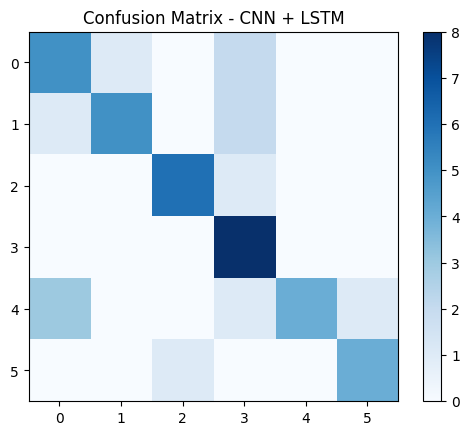

In [ ]:
y_pred = np.argmax(hybrid_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - CNN + LSTM")
plt.colorbar()
plt.show()


This cell provides an enhanced visualization of the `hybrid_model`'s performance. Similar to the previous cell, it calculates predictions and generates a `classification_report`. However, it uses the `seaborn` library to create a more aesthetically pleasing and informative heatmap for the confusion matrix, including annotated values and clear axis labels, making it easier to interpret the model's strengths and weaknesses for each action class.

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step
                precision    recall  f1-score   support

ApplyEyeMakeup       0.56      0.62      0.59         8
 ApplyLipstick       0.83      0.62      0.71         8
       Archery       0.86      0.86      0.86         7
  BabyCrawling       0.57      1.00      0.73         8
   BalanceBeam       1.00      0.44      0.62         9
  BandMarching       0.80      0.80      0.80         5

      accuracy                           0.71        45
     macro avg       0.77      0.73      0.72        45
  weighted avg       0.77      0.71      0.71        45



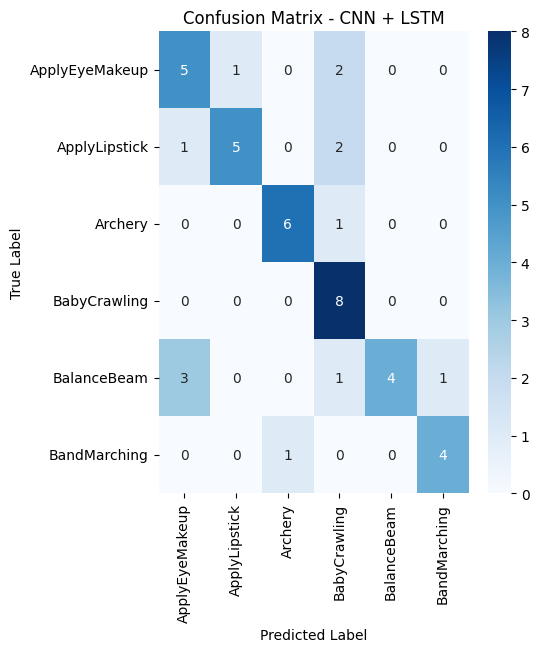

In [ ]:
import seaborn as sns
y_pred = np.argmax(hybrid_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Confusion Matrix - CNN + LSTM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


This cell saves the trained models to disk. It saves the `cnn` (baseline CNN), `lstm_model` (LSTM trained on extracted features), and `hybrid_model` (end-to-end CNN-LSTM) as `.keras` files. This allows the models to be loaded and used later without needing to retrain them, which is useful for deployment or further analysis.

In [ ]:
cnn.save("cnn_baseline.keras")
lstm_model.save("lstm_model.keras")
hybrid_model.save("cnn_lstm_hybrid.keras")
